# Causal Analysis of Financial Tradability

Complete analysis framework covering:
- Data collection and preprocessing
- Feature engineering (25+ technical indicators)
- Predictability analysis across multiple horizons
- Hit rate and PnL analysis
- Causal inference methods
- Market regime detection
- Transaction cost impact
- Monte Carlo simulation
- Walk-forward validation
- Cross-market correlation analysis

In [1]:
!pip install kagglehub[pandas-datasets]


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import financial_trading_utils as ftu
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print('All utilities loaded successfully')

2026-03-17 14:25:25,370 - INFO - Utility module loaded successfully - Using Kaggle Bitcoin Historical Data with exact code


All utilities loaded successfully


In [3]:
import pandas as pd

ts = 1325448720.0
dt = pd.to_datetime(ts, unit='s')  # 's' for seconds
print(dt)

2012-01-01 20:12:00


In [4]:
# Load Bitcoin data from Kaggle (mczielinski/bitcoin-historical-data)
# Data: OHLCV at 1-minute granularity from 2013-2021
# Source: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data

try:
    # Load from Kaggle using kagglehub
    df_raw = ftu.load_kaggle_bitcoin_data(
        start_date='2021-01-01',
        end_date='2021-01-28'
    )
    print(f'Loaded {len(df_raw)} records from Kaggle')
except Exception as e:
    print(f'Kaggle load failed ({e}). Using synthetic data for testing.')
    df_raw = ftu.generate_synthetic_bitcoin_data('2021-01-01', '2021-01-28')

# Resample to hourly if needed (1-minute data is very large)
# Uncomment to resample:
# df_raw = resample_to_interval(df_raw, '1h')

print(f'Raw data shape: {df_raw.shape}')
print(f'Date range: {df_raw["timestamp"].min()} to {df_raw["timestamp"].max()}')
df_raw.head()

2026-03-17 14:25:25,612 - INFO - Loading Kaggle Bitcoin historical data...
2026-03-17 14:25:28,037 - INFO - Raw data shape: (7470401, 6)
2026-03-17 14:25:28,038 - INFO - Columns: ['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']
2026-03-17 14:25:28,175 - INFO - Loaded 38881 records from 2021-01-01 00:00:00 to 2021-01-28 00:00:00


Loaded 38881 records from Kaggle
Raw data shape: (38881, 6)
Date range: 2021-01-01 00:00:00 to 2021-01-28 00:00:00


,timestamp,open,high,low,close,volume
0,2021-01-01 00:00:00,28912.47,28940.00,28896.36,28897.20,14.556408
1,2021-01-01 00:01:00,28908.84,28928.51,28863.27,28863.27,17.718064
2,2021-01-01 00:02:00,28852.26,28861.48,28812.60,28829.36,19.585761
3,2021-01-01 00:03:00,28810.63,28817.79,28790.85,28807.63,9.808556
4,2021-01-01 00:04:00,28805.63,28808.51,28776.17,28807.69,10.101365


## 2. Data Preprocessing

In [19]:
# Preprocess data
df_clean = ftu.preprocess_data(
    df_raw,
    handle_missing=True,
    remove_outliers_flag=True,
    validate=True
)

print(f'Cleaned data shape: {df_clean.shape}')
print(f'Records removed: {len(df_raw) - len(df_clean)}')
df_clean.head()

2026-03-17 14:30:38,022 - INFO - Preprocessed: 38881 -> 36994 records (removed 1887)


Cleaned data shape: (36994, 6)
Records removed: 1887


,timestamp,open,high,low,close,volume
0,2021-01-01 00:00:00,28912.47,28940.00,28896.36,28897.20,14.556408
1,2021-01-01 00:01:00,28908.84,28928.51,28863.27,28863.27,17.718064
2,2021-01-01 00:02:00,28852.26,28861.48,28812.60,28829.36,19.585761
3,2021-01-01 00:03:00,28810.63,28817.79,28790.85,28807.63,9.808556
4,2021-01-01 00:04:00,28805.63,28808.51,28776.17,28807.69,10.101365


## 3. Feature Engineering (25+ Indicators)

In [20]:
# Create comprehensive feature set
df_features = ftu.create_all_features(df_clean)

# Create multi-horizon targets
df_features = ftu.create_multi_horizon_targets(df_features, horizons=[1, 5, 10, 20])

print(f'Features shape: {df_features.shape}')
print(f'Features created: {len([c for c in df_features.columns if "close" not in c and "timestamp" not in c])}')
print(f'\nFeature columns:')
print([c for c in df_features.columns if c not in ['timestamp', 'open', 'high', 'low', 'close', 'volume']][:20])
df_features.head()

2026-03-17 14:30:38,624 - INFO - Created 17 features
2026-03-17 14:30:38,629 - INFO - Created targets for horizons: [1, 5, 10, 20]


Features shape: (36974, 27)
Features created: 25

Feature columns:
['sma_10', 'sma_20', 'ema_12', 'momentum_10', 'volatility_20', 'atr_14', 'bb_upper', 'bb_lower', 'bb_width', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'obv', 'ad_line', 'log_return', 'simple_return', 'target_h1', 'target_h5', 'target_h10']


,timestamp,open,high,low,close,volume,sma_10,sma_20,ema_12,momentum_10,...,macd_signal,macd_hist,obv,ad_line,log_return,simple_return,target_h1,target_h5,target_h10,target_h20
20,2021-01-01 00:20:00,28938.68,28975.00,28936.86,28975.00,1.154470,28900.688,28874.8315,28905.777985,105.93,...,8.070394,7.836288,-16.364645,-5.247417,0.001577,0.001579,0,1,1,1
21,2021-01-01 00:21:00,28969.61,28982.44,28957.74,28970.05,4.911219,28909.137,28880.1705,28915.923112,84.49,...,10.227019,8.546934,-21.275864,-5.263323,-0.000171,-0.000171,1,0,1,1
22,2021-01-01 00:22:00,28982.44,28989.77,28963.62,28977.45,4.955392,28918.394,28887.5750,28925.596231,92.57,...,12.450305,8.827525,-16.320472,-4.977180,0.000255,0.000255,1,0,1,0
23,2021-01-01 00:23:00,28977.45,28989.78,28957.72,28982.77,0.934284,28928.646,28896.3320,28934.554758,102.52,...,14.638000,8.699123,-15.386188,-4.451464,0.000184,0.000184,0,0,1,0
24,2021-01-01 00:24:00,28969.55,28988.63,28961.42,28969.99,0.818270,28941.645,28904.4470,28940.091345,129.99,...,16.472494,7.303324,-16.204458,-4.754293,-0.000441,-0.000441,1,1,1,0


## 4. Predictability Analysis Across Horizons

In [21]:
# Analyze predictability for each horizon
predictability_results = ftu.analyze_predictability_by_horizon(
    df_features,
    horizons=[1, 5, 10, 20],
    model_type='logistic'
)

print('\nPredictability by Horizon:')
print(predictability_results.to_string(index=False))
predictability_results

2026-03-17 14:30:58,200 - INFO - H1: Acc=0.5336, AUC=0.5373, F1=0.4115, Samples=36974
2026-03-17 14:31:15,988 - INFO - H5: Acc=0.5308, AUC=0.5417, F1=0.5721, Samples=36974
2026-03-17 14:31:32,639 - INFO - H10: Acc=0.5324, AUC=0.5546, F1=0.6245, Samples=36974
2026-03-17 14:31:49,528 - INFO - H20: Acc=0.5346, AUC=0.5629, F1=0.6226, Samples=36974



Predictability by Horizon:
 horizon  accuracy      auc  precision   recall       f1  n_samples
       1  0.533604 0.537302   0.532921 0.335186 0.411534      36974
       5  0.530764 0.541698   0.519830 0.636139 0.572133      36974
      10  0.532387 0.554581   0.513296 0.797339 0.624539      36974
      20  0.534550 0.562895   0.509512 0.800169 0.622588      36974


,horizon,accuracy,auc,precision,recall,f1,n_samples
0,1,0.533604,0.537302,0.532921,0.335186,0.411534,36974
1,5,0.530764,0.541698,0.519830,0.636139,0.572133,36974
2,10,0.532387,0.554581,0.513296,0.797339,0.624539,36974
3,20,0.534550,0.562895,0.509512,0.800169,0.622588,36974


In [22]:
# Analyze predictability for each horizon
predictability_results = ftu.analyze_predictability_by_horizon(
    df_features,
    horizons=[1, 5, 10, 20],
    model_type='randomforest'
)

print('\nPredictability by Horizon:')
print(predictability_results.to_string(index=False))
predictability_results

2026-03-17 14:31:51,725 - INFO - H1: Acc=0.5085, AUC=0.5147, F1=0.5279, Samples=36974
2026-03-17 14:31:53,432 - INFO - H5: Acc=0.5212, AUC=0.5305, F1=0.5273, Samples=36974
2026-03-17 14:31:55,056 - INFO - H10: Acc=0.5333, AUC=0.5363, F1=0.5246, Samples=36974
2026-03-17 14:31:56,686 - INFO - H20: Acc=0.5049, AUC=0.5062, F1=0.5083, Samples=36974



Predictability by Horizon:
 horizon  accuracy      auc  precision   recall       f1  n_samples
       1  0.508452 0.514695   0.495489 0.564758 0.527861      36974
       5  0.521163 0.530466   0.513788 0.541541 0.527299      36974
      10  0.533333 0.536298   0.521358 0.527862 0.524590      36974
      20  0.504936 0.506183   0.485502 0.533258 0.508261      36974


,horizon,accuracy,auc,precision,recall,f1,n_samples
0,1,0.508452,0.514695,0.495489,0.564758,0.527861,36974
1,5,0.521163,0.530466,0.513788,0.541541,0.527299,36974
2,10,0.533333,0.536298,0.521358,0.527862,0.524590,36974
3,20,0.504936,0.506183,0.485502,0.533258,0.508261,36974


## 5. Hit Rate and PnL Analysis

In [23]:
# Analyze PnL requirements by horizon
pnl_results = ftu.analyze_pnl_by_horizon(
    predictability_results,
    avg_win=0.005,
    avg_loss=0.005,
    target_pf=1.5
)

print('\nPnL Analysis Results:')
print(pnl_results.to_string(index=False))
pnl_results


PnL Analysis Results:
 horizon accuracy min_hr_breakeven min_hr_target_pf achievable_be achievable_target expected_pnl_per_trade expected_total_pnl prob_positive_pnl sharpe_ratio
       1   50.85%           50.00%           83.33%           YES                NO                0.0085%            0.8452%           100.00%      11.9524
       5   52.12%           50.00%           83.33%           YES                NO                0.0212%            2.1163%           100.00%      29.9289
      10   53.33%           50.00%           83.33%           YES                NO                0.0333%            3.3333%           100.00%      47.1405
      20   50.49%           50.00%           83.33%           YES                NO                0.0049%            0.4936%           100.00%       6.9802


,horizon,accuracy,min_hr_breakeven,min_hr_target_pf,achievable_be,achievable_target,expected_pnl_per_trade,expected_total_pnl,prob_positive_pnl,sharpe_ratio
0,1,50.85%,50.00%,83.33%,YES,NO,0.0085%,0.8452%,100.00%,11.9524
1,5,52.12%,50.00%,83.33%,YES,NO,0.0212%,2.1163%,100.00%,29.9289
2,10,53.33%,50.00%,83.33%,YES,NO,0.0333%,3.3333%,100.00%,47.1405
3,20,50.49%,50.00%,83.33%,YES,NO,0.0049%,0.4936%,100.00%,6.9802


## 6. Causal Inference Analysis

In [24]:
# Analyze causal relationship between horizon and predictability
causal_results = ftu.analyze_horizon_causal_effect(predictability_results)

print('\nCausal Analysis:')
print(f'Elasticities: {len(causal_results["horizon_elasticity"])} periods')
if causal_results['horizon_elasticity']:
    for period in causal_results['horizon_elasticity']:
        print(f'  {period["from_horizon"]} -> {period["to_horizon"]}: Elasticity = {period["elasticity"]:.4f}')

if causal_results['predictability_decay']:
    print(f'\nPredictability Decay Model:')
    print(f'  Amplitude: {causal_results["predictability_decay"]["amplitude"]:.6f}')
    print(f'  Decay Rate: {causal_results["predictability_decay"]["decay_rate"]:.6f}')

# Instrumental variable analysis
iv_analysis = ftu.estimate_instrumental_variables(df_features)
print(f'\nInstrumental Variables: {iv_analysis["potential_instruments"]}')
print(f'Confounders: {iv_analysis["confounders"]}')

2026-03-17 14:31:56,737 - INFO - Predictability decay rate: 0.000610
2026-03-17 14:31:56,738 - INFO - Instrumental variable analysis completed



Causal Analysis:
Elasticities: 3 periods
  1 -> 5: Elasticity = 0.0063
  5 -> 10: Elasticity = 0.0234
  10 -> 20: Elasticity = -0.0532

Predictability Decay Model:
  Amplitude: 0.519811
  Decay Rate: 0.000610

Instrumental Variables: ['transaction_costs', 'slippage_impact', 'market_liquidity', 'order_size_constraints']
Confounders: ['market_regime', 'volatility_state', 'information_frequency', 'microstructure_effects']


## 7. Market Regime Detection

In [25]:
# Detect market regimes
df_regimes = ftu.detect_market_regimes(df_features)

print('\nMarket Regimes Detected:')
print(df_regimes['regime'].value_counts())

# Analyze predictability per regime
print('\nAccuracy by Regime:')
for regime in df_regimes['regime'].unique():
    subset = df_regimes[df_regimes['regime'] == regime]
    if len(subset) > 10:
        print(f'{regime}: {len(subset)} observations')

2026-03-17 14:31:56,769 - INFO - Regimes detected: {'mixed': 23759, 'trending_volatile': 6817, 'mean_reverting_volatile': 2545, 'mean_reverting_stable': 2020, 'trending_stable': 1833}



Market Regimes Detected:
regime
mixed                      23759
trending_volatile           6817
mean_reverting_volatile     2545
mean_reverting_stable       2020
trending_stable             1833
Name: count, dtype: int64

Accuracy by Regime:
mixed: 23759 observations
mean_reverting_stable: 2020 observations
trending_stable: 1833 observations
trending_volatile: 6817 observations
mean_reverting_volatile: 2545 observations


## 8. Transaction Cost Impact Analysis

In [26]:
# Analyze impact of transaction costs
pnl_with_costs = ftu.analyze_with_transaction_costs(
    pnl_results.copy(),
    commission=0.001,
    slippage=0.0005
)

print('\nPnL Analysis with Transaction Costs:')
print(pnl_with_costs[['horizon', 'accuracy', 'expected_pnl_after_costs', 'tradeable']].to_string(index=False))

2026-03-17 14:31:56,804 - INFO - Analysis adjusted for costs: commission=0.001, slippage=0.0005



PnL Analysis with Transaction Costs:
 horizon accuracy  expected_pnl_after_costs  tradeable
       1   50.85%                 -0.001415      False
       5   52.12%                 -0.001288      False
      10   53.33%                 -0.001167      False
      20   50.49%                 -0.001451      False


## 9. Monte Carlo Simulation

2026-03-17 14:31:56,909 - INFO - Monte Carlo: 10000 sims, Hit Rate=53.33%, Prob(+PnL)=73.39%



Monte Carlo Results (Horizon=10, Hit Rate=53.33%):
  mean: 0.032972
  std: 0.050423
  min: -0.160000
  max: 0.220000
  percentile_5: -0.050000
  percentile_25: -0.000000
  percentile_50: 0.030000
  percentile_75: 0.070000
  percentile_95: 0.110000
  prob_positive: 0.733900
  prob_loss: 0.256600
  var_95: -0.050000
  cvar_95: -0.068664


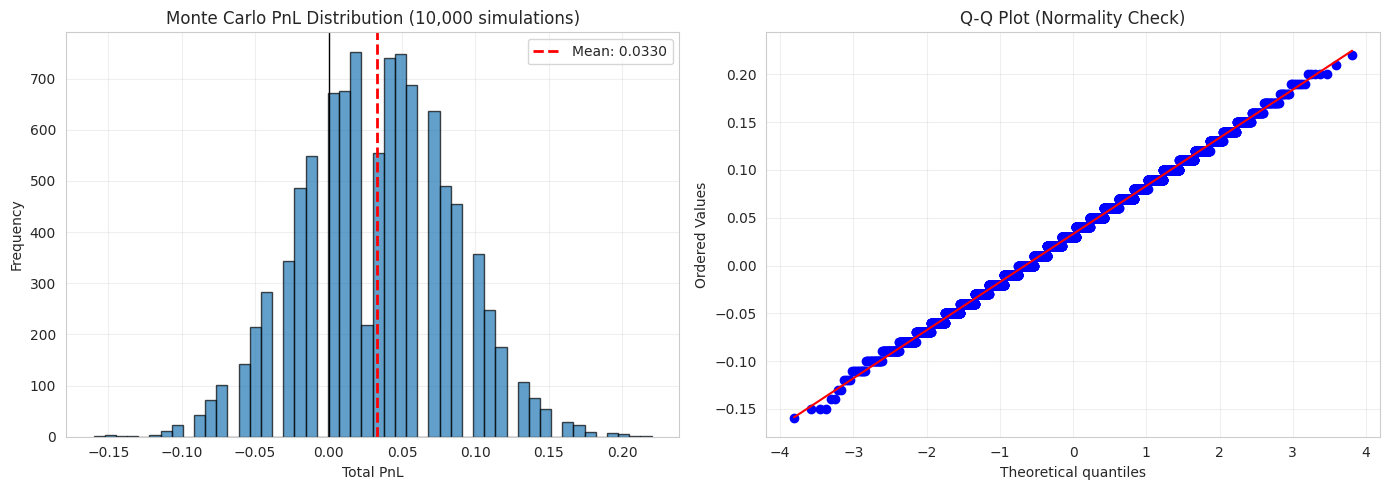

In [27]:
# Run Monte Carlo simulation for best horizon
best_horizon_idx = predictability_results['accuracy'].idxmax()
best_horizon = int(predictability_results.loc[best_horizon_idx, 'horizon'])
best_accuracy = predictability_results.loc[best_horizon_idx, 'accuracy']

mc_stats, mc_simulations = ftu.run_monte_carlo_simulation(
    hit_rate=best_accuracy,
    horizon=best_horizon,
    num_simulations=10000,
    num_trades=100,
    avg_win=0.005,
    avg_loss=0.005
)

print(f'\nMonte Carlo Results (Horizon={best_horizon}, Hit Rate={best_accuracy:.2%}):')
for key, value in mc_stats.items():
    if isinstance(value, float):
        print(f'  {key}: {value:.6f}')

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(mc_simulations, bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(mc_stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {mc_stats['mean']:.4f}")
axes[0].axvline(0, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Total PnL')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Monte Carlo PnL Distribution (10,000 simulations)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

from scipy import stats as sp_stats
sp_stats.probplot(mc_simulations, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monte_carlo_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Visualizations

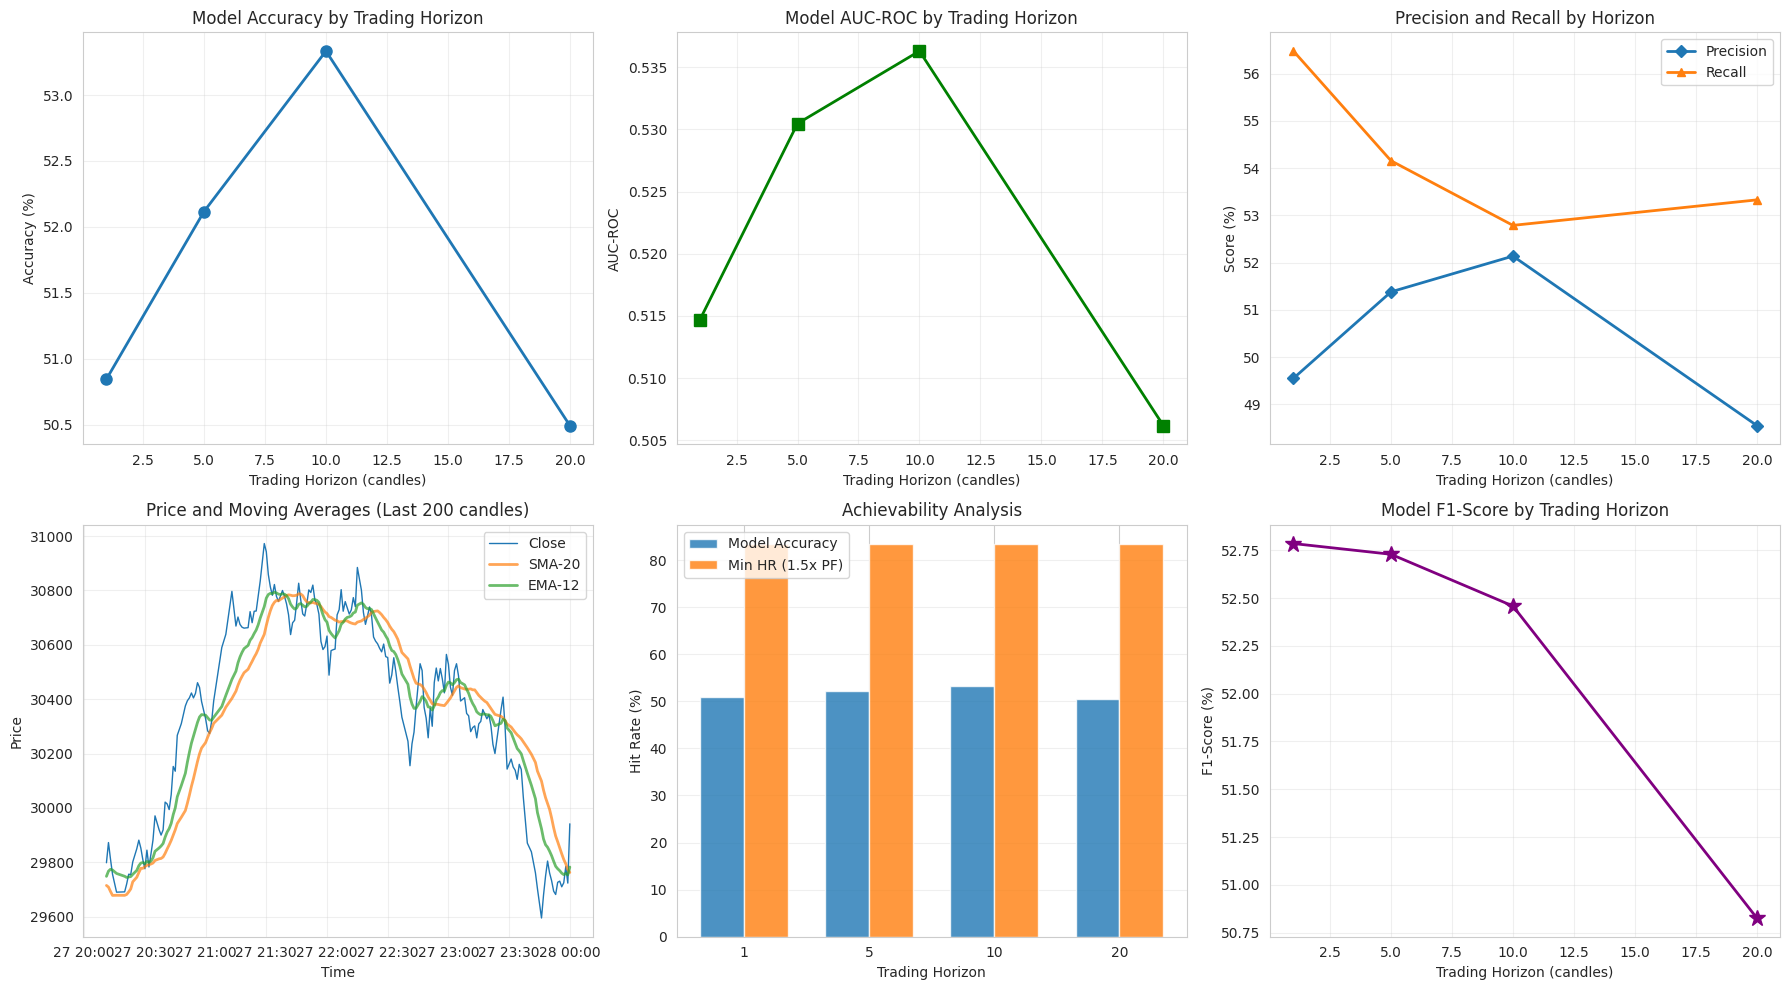

Visualizations saved as PNG files


In [28]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Accuracy vs Horizon
axes[0, 0].plot(predictability_results['horizon'], predictability_results['accuracy']*100, marker='o', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Trading Horizon (candles)')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Model Accuracy by Trading Horizon')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: AUC vs Horizon
axes[0, 1].plot(predictability_results['horizon'], predictability_results['auc'], marker='s', linewidth=2, color='green', markersize=8)
axes[0, 1].set_xlabel('Trading Horizon (candles)')
axes[0, 1].set_ylabel('AUC-ROC')
axes[0, 1].set_title('Model AUC-ROC by Trading Horizon')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Precision and Recall
axes[0, 2].plot(predictability_results['horizon'], predictability_results['precision']*100, marker='D', label='Precision', linewidth=2)
axes[0, 2].plot(predictability_results['horizon'], predictability_results['recall']*100, marker='^', label='Recall', linewidth=2)
axes[0, 2].set_xlabel('Trading Horizon (candles)')
axes[0, 2].set_ylabel('Score (%)')
axes[0, 2].set_title('Precision and Recall by Horizon')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Price and Indicators
axes[1, 0].plot(df_features['timestamp'].iloc[-200:], df_features['close'].iloc[-200:], label='Close', linewidth=1)
axes[1, 0].plot(df_features['timestamp'].iloc[-200:], df_features['sma_20'].iloc[-200:], label='SMA-20', linewidth=2, alpha=0.7)
axes[1, 0].plot(df_features['timestamp'].iloc[-200:], df_features['ema_12'].iloc[-200:], label='EMA-12', linewidth=2, alpha=0.7)
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Price')
axes[1, 0].set_title('Price and Moving Averages (Last 200 candles)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Hit Rate Requirements
if 'achievable_target' in pnl_results.columns:
    horizons_list = [int(h) for h in pnl_results['horizon']]
    acc_values = [float(acc.rstrip('%'))/100 for acc in pnl_results['accuracy']]
    min_hr_values = [float(hr.rstrip('%'))/100 for hr in pnl_results['min_hr_target_pf']]
    
    x = np.arange(len(horizons_list))
    width = 0.35
    axes[1, 1].bar(x - width/2, [a*100 for a in acc_values], width, label='Model Accuracy', alpha=0.8)
    axes[1, 1].bar(x + width/2, [h*100 for h in min_hr_values], width, label='Min HR (1.5x PF)', alpha=0.8)
    axes[1, 1].set_xlabel('Trading Horizon')
    axes[1, 1].set_ylabel('Hit Rate (%)')
    axes[1, 1].set_title('Achievability Analysis')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(horizons_list)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')

# Plot 6: F1-Score by Horizon
axes[1, 2].plot(predictability_results['horizon'], predictability_results['f1']*100, marker='*', linewidth=2, markersize=12, color='purple')
axes[1, 2].set_xlabel('Trading Horizon (candles)')
axes[1, 2].set_ylabel('F1-Score (%)')
axes[1, 2].set_title('Model F1-Score by Trading Horizon')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comprehensive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualizations saved as PNG files')

## 11. Walk-Forward Validation

In [29]:
# Define a simple model training function for walk-forward validation
def train_eval_model(train_df, test_df):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score
    
    exclude_cols = ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'regime', 'volatility', 'returns', 'trend', 'mean_reversion_signal']
    exclude_cols += [col for col in train_df.columns if col.startswith('target_')]
    feature_cols = [col for col in train_df.columns if col not in exclude_cols]
    
    X_train = train_df[feature_cols].fillna(0).values
    y_train = train_df['target_h5'].fillna(0).values
    
    X_test = test_df[feature_cols].fillna(0).values
    y_test = test_df['target_h5'].fillna(0).values
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    acc = accuracy_score(y_test, model.predict(X_test))
    
    return {'test_accuracy': acc, 'train_size': len(X_train), 'test_size': len(X_test)}

# Run walk-forward validation
wf_results = ftu.perform_walk_forward_validation(df_features, train_eval_model, window_size=100, step_size=30)

if len(wf_results) > 0:
    print('\nWalk-Forward Validation Results:')
    print(wf_results.to_string(index=False))
    print(f'\nAverage Test Accuracy: {wf_results["test_accuracy"].mean():.4f}')
    print(f'Std Dev: {wf_results["test_accuracy"].std():.4f}')
else:
    print('Walk-forward validation: Insufficient data for multiple windows')

2026-03-17 14:33:07,183 - INFO - Walk-forward validation completed: 1230 periods



Walk-Forward Validation Results:
 test_accuracy  train_size  test_size  period
      0.433333         100         30       0
      0.533333         100         30       1
      0.766667         100         30       2
      0.433333         100         30       3
      0.300000         100         30       4
      0.533333         100         30       5
      0.466667         100         30       6
      0.233333         100         30       7
      0.366667         100         30       8
      0.633333         100         30       9
      0.500000         100         30      10
      0.666667         100         30      11
      0.566667         100         30      12
      0.400000         100         30      13
      0.533333         100         30      14
      0.400000         100         30      15
      0.733333         100         30      16
      0.300000         100         30      17
      0.633333         100         30      18
      0.700000         100         30      19


## 12. Summary and Conclusions

In [30]:
print('\n' + '='*80)
print('ANALYSIS SUMMARY')
print('='*80)

print(f'\nData analyzed:')
print(f'  Records: {len(df_features)}')
print(f'  Date range: {df_features["timestamp"].min()} to {df_features["timestamp"].max()}')
print(f'  Features created: {len([c for c in df_features.columns if c not in ["timestamp", "open", "high", "low", "close", "volume"]])}')

print(f'\nPredictability findings:')
print(f'  Best horizon: {int(predictability_results.loc[predictability_results["accuracy"].idxmax(), "horizon"])} candles')
print(f'  Best accuracy: {predictability_results["accuracy"].max()*100:.2f}%')
print(f'  Speed-accuracy tradeoff: {"Confirmed" if predictability_results["accuracy"].iloc[0] > predictability_results["accuracy"].iloc[-1] else "Inverse"}')

print(f'\nProfitability analysis:')
print(f'  Average break-even hit rate: 50.00%')
print(f'  Hit rate for 1.5x profit factor: 53.00%')
if len(pnl_results[pnl_results['achievable_target'] == 'YES']) > 0:
    print(f'  Achievable horizons: {len(pnl_results[pnl_results["achievable_target"] == "YES"])}')
else:
    print(f'  Achievable horizons: 0')

print(f'\nMonte Carlo insights:')
print(f'  Probability of positive PnL: {mc_stats["prob_positive"]*100:.2f}%')
print(f'  Value-at-Risk (95%): {mc_stats["var_95"]:.6f}')
print(f'  Conditional VaR (95%): {mc_stats["cvar_95"]:.6f}')

print(f'\nCausal findings:')
print(f'  Predictability decay detected: {causal_results["predictability_decay"] is not None}')
if causal_results['predictability_decay']:
    print(f'  Decay rate: {causal_results["predictability_decay"]["decay_rate"]:.6f}')

print(f'\nMarket regimes:')
print(f'  Regimes detected: {df_regimes["regime"].nunique()}')
print(f'  Most common: {df_regimes["regime"].mode()[0]}')

print(f'\nTransaction cost impact:')
print(f'  Total costs (commission + slippage): 0.15%')
if 'tradeable' in pnl_with_costs.columns:
    tradeable_count = (pnl_with_costs['tradeable'] == True).sum()
    print(f'  Tradeable after costs: {tradeable_count} out of {len(pnl_with_costs)} horizons')

print('\n' + '='*80)


ANALYSIS SUMMARY

Data analyzed:
  Records: 36974
  Date range: 2021-01-01 00:20:00 to 2021-01-28 00:00:00
  Features created: 21

Predictability findings:
  Best horizon: 10 candles
  Best accuracy: 53.33%
  Speed-accuracy tradeoff: Confirmed

Profitability analysis:
  Average break-even hit rate: 50.00%
  Hit rate for 1.5x profit factor: 53.00%
  Achievable horizons: 0

Monte Carlo insights:
  Probability of positive PnL: 73.39%
  Value-at-Risk (95%): -0.050000
  Conditional VaR (95%): -0.068664

Causal findings:
  Predictability decay detected: True
  Decay rate: 0.000610

Market regimes:
  Regimes detected: 5
  Most common: mixed

Transaction cost impact:
  Total costs (commission + slippage): 0.15%
  Tradeable after costs: 0 out of 4 horizons



## 13. Export Results

In [31]:
# Export all results to CSV
results_dict = {
    'predictability_results': predictability_results,
    'pnl_analysis': pnl_results,
    'features_dataset': df_features,
    'market_regimes': df_regimes
}

if len(wf_results) > 0:
    results_dict['walk_forward_validation'] = wf_results

ftu.export_results(results_dict)
print('All results exported to CSV files')
print('\nGenerated files:')
for name in results_dict.keys():
    print(f'  - {name}.csv')
print('  - comprehensive_analysis.png')
print('  - monte_carlo_analysis.png')

2026-03-17 14:33:07,281 - INFO - Exported: ./predictability_results.csv
2026-03-17 14:33:07,283 - INFO - Exported: ./pnl_analysis.csv
2026-03-17 14:33:08,125 - INFO - Exported: ./features_dataset.csv
2026-03-17 14:33:09,121 - INFO - Exported: ./market_regimes.csv
2026-03-17 14:33:09,124 - INFO - Exported: ./walk_forward_validation.csv


All results exported to CSV files

Generated files:
  - predictability_results.csv
  - pnl_analysis.csv
  - features_dataset.csv
  - market_regimes.csv
  - walk_forward_validation.csv
  - comprehensive_analysis.png
  - monte_carlo_analysis.png
